In [1]:
import re
from dataclasses import dataclass
from typing import Callable, Optional

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import HuberRegressor

import jupyter_black

pd.set_option("display.max_columns", None)
jupyter_black.load()

In [2]:
EPS = 1e-12
MISSING_SCORE = -2

SYSTEM_SCORE = {
    "Windows": 0.0,
    "MacOS": 0.5,
    "Linux": 1.0,
    "NoOS": 1.0,
}

In [3]:
def parse_brand_reliability(df):
    return df["Brand Reliability"].str.replace("%", "").astype(float) / 100


def parse_system(df):
    return df["System"].map(SYSTEM_SCORE)


def delta_scorer(
    values: pd.Series,
    baseline: float,
    invert: bool = False,
    missing_score: float = MISSING_SCORE,
) -> pd.Series:
    numeric_values = pd.to_numeric(values, errors="coerce")
    scores = pd.Series(missing_score, index=values.index, dtype=float)

    valid = numeric_values.notna()
    delta = (numeric_values[valid] - baseline) / (abs(baseline) + EPS)

    if invert:
        delta = -delta

    scores.loc[valid] = np.tanh(delta)
    return scores


def ratio_scorer(
    values: pd.Series,
    baseline: float,
    invert: bool = False,
    missing_score: float = MISSING_SCORE,
) -> pd.Series:
    numeric_values = pd.to_numeric(values, errors="coerce")
    scores = pd.Series(missing_score, index=values.index, dtype=float)

    valid = numeric_values.notna() & (numeric_values > 0)
    log_ratio = np.log(numeric_values[valid] / baseline)

    if invert:
        log_ratio = -log_ratio

    scores.loc[valid] = np.tanh(log_ratio)
    return scores


def distance_scorer(
    values: pd.Series,
    baseline: float,
    invert: bool = False,
    missing_score: float = MISSING_SCORE,
) -> pd.Series:
    numeric_values = pd.to_numeric(values, errors="coerce")
    scores = pd.Series(missing_score, index=values.index, dtype=float)

    valid = numeric_values.notna()
    distance = np.abs(numeric_values[valid] - baseline) / (abs(baseline) + EPS)

    scores.loc[valid] = -np.tanh(distance)
    return scores


def categorical_scorer(
    values: pd.Series,
    baseline: float,
    invert: bool = False,
    missing_score: float = MISSING_SCORE,
) -> pd.Series:
    numeric_values = pd.to_numeric(values, errors="coerce")
    scores = pd.Series(missing_score, index=values.index, dtype=float)

    valid = numeric_values.notna()
    delta = numeric_values[valid] - baseline

    if invert:
        delta = -delta

    scores.loc[valid] = np.clip(delta, -1.0, 1.0)
    return scores

In [4]:
@dataclass
class FeatureConfig:
    name: str
    raw_data_name: str
    parse_function: Optional[Callable]
    score_function: Callable
    weight: float
    invert: bool
    baseline_value: float

In [5]:
FEATURES = [
    FeatureConfig(
        "CPU Score",
        "CPU Performance",
        None,
        delta_scorer,
        0.15,
        False,
        baseline_value=52.4,
    ),
    FeatureConfig(
        "GPU Score",
        "GPU Performance",
        None,
        delta_scorer,
        0.14,
        False,
        baseline_value=58.1,
    ),
    FeatureConfig(
        "VRAM Score",
        "VRAM",
        None,
        ratio_scorer,
        0.12,
        False,
        baseline_value=8,
    ),
    FeatureConfig(
        "RAM Score",
        "RAM",
        None,
        ratio_scorer,
        0.12,
        False,
        baseline_value=32,
    ),
    FeatureConfig(
        "Battery Score",
        "Battery",
        None,
        delta_scorer,
        0.09,
        False,
        baseline_value=99,
    ),
    FeatureConfig(
        "New Score",
        "New",
        None,
        categorical_scorer,
        0.06,
        False,
        baseline_value=1,
    ),
    FeatureConfig(
        "Weight Score",
        "Weight",
        None,
        delta_scorer,
        0.05,
        True,
        baseline_value=2.3,
    ),
    FeatureConfig(
        "Storage Score",
        "Storage",
        None,
        ratio_scorer,
        0.04,
        False,
        baseline_value=2000,
    ),
    FeatureConfig(
        "System Score",
        "System",
        parse_system,
        categorical_scorer,
        0.03,
        False,
        baseline_value=0,
    ),
    FeatureConfig(
        "Screen Size Score",
        "Screen Size",
        None,
        distance_scorer,
        0.03,
        False,
        baseline_value=16,
    ),
    FeatureConfig(
        "Resolution Score",
        "Resolution",
        None,
        distance_scorer,
        0.03,
        False,
        baseline_value=9216000,
    ),
    FeatureConfig(
        "Temperature Score",
        "Temperature",
        None,
        delta_scorer,
        0.12,
        True,
        baseline_value=49,
    ),
    FeatureConfig(
        "Brand Reliability Score",
        "Brand Reliability",
        parse_brand_reliability,
        delta_scorer,
        0.02,
        True,
        baseline_value=0.036,
    ),
]
print(sum(f.weight for f in FEATURES) - 1.0)

0.0


In [6]:
raw = pd.read_csv("laptops.csv")
raw

,URL,Laptop Name,Brand,Brand Reliability,CPU,CPU Performance,GPU,GPU Performance,VRAM,RAM,Battery,Screen Size,Resolution,System,Weight,Storage,Temperature,New,Price
0,https://bestware.com/en/schenker-work-17-m23.h...,Schenker,Schenker,NaN,i7-1360P,49.3,Iris Xe Graphics G7 96EUs,13.30,0,32,73.00,17.3,2073600,NoOS,2.25,1000,39.1,1,5191.00
1,https://allegro.pl/oferta/lenovo-thinkpad-t15p...,Thinkpad T15p Gen2,Lenovo,2.60%,i7-11800H,45.1,GTX 1650,25.30,4,32,68.00,15.6,8294400,Windows,2.07,1000,39.8,1,5989.00
2,NaN,Legion 5 Pro-16,Lenovo,2.60%,Ryzen 5 5600H,40.6,RTX 3050 4GB Laptop GPU,31.70,4,16,80.00,16.0,4096000,Linux,2.45,512,39.9,1,4999.00
3,NaN,Huawei Matebook 16,Huawei,1.1%,Ryzen 7 5800H,43.5,Radeon RX Vega 8 (Ryzen 4000/5000),14.70,0,16,84.00,16.0,4233600,Windows,1.99,512,40.2,1,4548.00
4,https://tradingshenzhen.com/en/redmibook-14-re...,Xiaomi Redmibook 16 Pro,Xiaomi,NaN,Ultra 7 155H,50.9,Arc 8-Core iGPU,24.50,0,32,99.00,16.0,5898240,Windows,1.88,1000,40.3,1,4635.00
5,https://allegro.pl/oferta/lenovo-legion-slim-5...,Lenovo Legion Slim,Lenovo,2.60%,Ryzen 7 7840HS,54.9,GeForce RTX 4060,59.20,8,32,80.00,16.0,4096000,Windows,2.40,1000,40.6,1,6995.00
6,https://allegro.pl/oferta/apple-mac-book-pro-a...,Mac Book Pro,Apple,0.70%,M1 Max,37.8,M1 Max 24-Core GPU,39.10,0,64,99.60,16.0,7720704,MacOS,2.20,1024,42.3,0,7999.00
7,https://www.apple.com/pl/shop/buy-mac/macbook-...,MacBook Pro,Apple,0.70%,M4 Max,78.3,M4 Max 40-Core GPU,64.45,0,48,72.40,16.2,7720704,MacOS,2.15,1000,42.8,1,21499.00
8,https://www.x-kom.pl/p/1246865-notebook-laptop...,ASUS Vivobook S15,Asus,3.30%,Qualcomm Snapdragon X Elite X1E-78-100,44.0,X Adreno X1-85,9.70,0,32,70.00,15.6,4665600,Windows,1.42,1000,43.6,1,4899.00
9,https://www.amazon.de/-/en/2023-Gram-Inch-Ultr...,LG Gram,LG,1.60%,i7-1360P,49.3,Iris Xe Graphics G7 96EUs,13.30,0,32,80.00,17.0,4096000,Windows,1.35,2000,43.9,1,6809.00


In [7]:
cleaned_data = pd.DataFrame()
cleaned_data["Laptop Name"] = raw["Laptop Name"]

for feature in FEATURES:
    if feature.parse_function:
        cleaned_data[feature.raw_data_name] = feature.parse_function(raw)
    else:
        cleaned_data[feature.raw_data_name] = raw[feature.raw_data_name]
        
cleaned_data["Price"] = raw["Price"]
cleaned_data

,Laptop Name,CPU Performance,GPU Performance,VRAM,RAM,Battery,New,Weight,Storage,System,Screen Size,Resolution,Temperature,Brand Reliability,Price
0,Schenker,49.3,13.30,0,32,73.00,1,2.25,1000,1.0,17.3,2073600,39.1,NaN,5191.00
1,Thinkpad T15p Gen2,45.1,25.30,4,32,68.00,1,2.07,1000,0.0,15.6,8294400,39.8,0.026,5989.00
2,Legion 5 Pro-16,40.6,31.70,4,16,80.00,1,2.45,512,1.0,16.0,4096000,39.9,0.026,4999.00
3,Huawei Matebook 16,43.5,14.70,0,16,84.00,1,1.99,512,0.0,16.0,4233600,40.2,0.011,4548.00
4,Xiaomi Redmibook 16 Pro,50.9,24.50,0,32,99.00,1,1.88,1000,0.0,16.0,5898240,40.3,NaN,4635.00
5,Lenovo Legion Slim,54.9,59.20,8,32,80.00,1,2.40,1000,0.0,16.0,4096000,40.6,0.026,6995.00
6,Mac Book Pro,37.8,39.10,0,64,99.60,0,2.20,1024,0.5,16.0,7720704,42.3,0.007,7999.00
7,MacBook Pro,78.3,64.45,0,48,72.40,1,2.15,1000,0.5,16.2,7720704,42.8,0.007,21499.00
8,ASUS Vivobook S15,44.0,9.70,0,32,70.00,1,1.42,1000,0.0,15.6,4665600,43.6,0.033,4899.00
9,LG Gram,49.3,13.30,0,32,80.00,1,1.35,2000,0.0,17.0,4096000,43.9,0.016,6809.00


In [8]:
score_dataframe = cleaned_data.copy()
for feature in FEATURES:
    col = feature.raw_data_name
    score_dataframe[feature.name] = feature.score_function(
        cleaned_data[col], feature.baseline_value, feature.invert
    )


score_dataframe["Total Score"] = sum(
    score_dataframe[feature.name] * feature.weight for feature in FEATURES
)
score_dataframe = score_dataframe.sort_values("Total Score", ascending=False)
score_dataframe

,Laptop Name,CPU Performance,GPU Performance,VRAM,RAM,Battery,New,Weight,Storage,System,Screen Size,Resolution,Temperature,Brand Reliability,Price,CPU Score,GPU Score,VRAM Score,RAM Score,Battery Score,New Score,Weight Score,Storage Score,System Score,Screen Size Score,Resolution Score,Temperature Score,Brand Reliability Score,Total Score
23,NEO 16,72.8,91.00,16,64,99.80,1,2.65,1000,1.0,16.0,4096000,47.0,NaN,14283.00,0.370768,0.512611,0.600000,0.600000,0.008081,0.0,-0.151010,-0.600000,1.0,-0.000000,-0.504672,0.040794,-2.000000e+00,2.203125e-01
11,ThinkPad X1 EXTREME G5,52.5,65.00,16,64,90.00,1,1.90,2048,0.0,16.0,9216000,52.0,0.026,12500.00,0.001908,0.118206,0.600000,0.600000,-0.090659,0.0,0.172181,0.023712,0.0,-0.000000,-0.000000,-0.061148,2.708471e-01,1.603124e-01
24,ProArt P16,59.0,63.90,8,64,90.00,1,1.81,2000,1.0,16.0,9216000,46.9,0.033,13999.00,0.125292,0.099498,0.000000,0.600000,-0.090659,0.0,0.209878,0.000000,1.0,-0.000000,-0.000000,0.042831,8.314097e-02,1.438606e-01
27,TUF Gaming F15,52.9,63.90,8,64,90.00,1,2.20,1000,1.0,15.6,2073600,46.4,0.033,7199.00,0.009542,0.099498,0.000000,0.600000,-0.090659,0.0,0.043451,-0.600000,1.0,-0.024995,-0.649827,0.053011,8.314097e-02,7.515364e-02
10,AERO 16 XE5,52.4,58.10,8,32,99.00,1,2.30,2000,0.0,16.0,9216000,49.0,0.036,10099.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-0.000000,0.000000,0.0,-0.000000,-0.000000,-0.000000,-1.927471e-16,-3.854941e-18
19,Laptop 16,55.1,44.10,8,64,85.00,1,2.42,1000,1.0,16.0,4096000,42.4,NaN,12678.00,0.051481,-0.236406,0.000000,0.600000,-0.140479,0.0,-0.052127,-0.600000,1.0,-0.000000,-0.504672,0.133885,-2.000000e+00,-1.698044e-03
5,Lenovo Legion Slim,54.9,59.20,8,32,80.00,1,2.40,1000,0.0,16.0,4096000,40.6,0.026,6995.00,0.047674,0.018931,0.000000,0.000000,-0.189597,0.0,-0.043451,-0.600000,0.0,-0.000000,-0.504672,0.169769,2.708471e-01,-2.278591e-02
7,MacBook Pro,78.3,64.45,0,48,72.40,1,2.15,1000,0.5,16.2,7720704,42.8,0.007,21499.00,0.457603,0.108861,-2.000000,0.384615,-0.262403,0.0,0.065125,-0.600000,0.5,-0.012499,-0.160841,0.125860,6.671312e-01,-1.160796e-01
25,Stellaris 16 - Gen6,67.8,59.20,8,64,99.00,1,2.50,1000,1.0,16.0,4096000,NaN,NaN,9427.46,0.285714,0.018931,0.000000,0.600000,0.000000,0.0,-0.086738,-0.600000,1.0,-0.000000,-0.504672,-2.000000,-2.000000e+00,-1.759697e-01
1,Thinkpad T15p Gen2,45.1,25.30,4,32,68.00,1,2.07,1000,0.0,15.6,8294400,39.8,0.026,5989.00,-0.138419,-0.511341,-0.600000,0.000000,-0.303283,0.0,0.099668,-0.600000,0.0,-0.024995,-0.099668,0.185580,2.708471e-01,-1.867160e-01


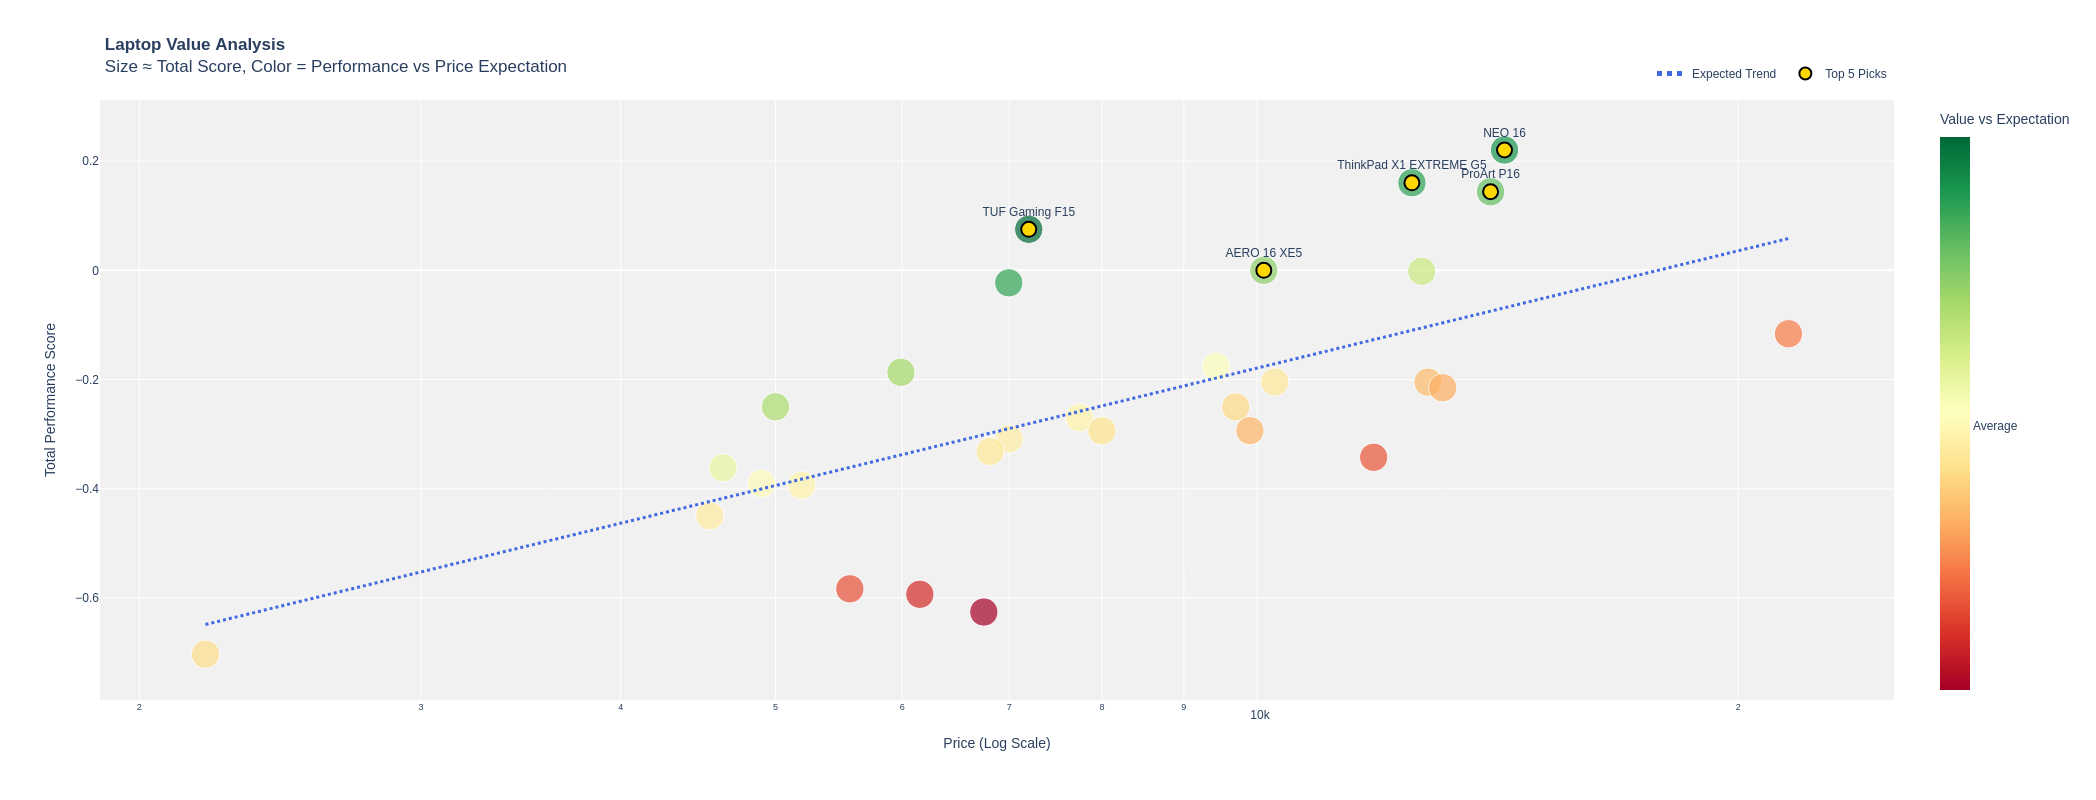

In [9]:
display_dataframe = score_dataframe.copy()
log_price = np.log(display_dataframe["Price"] + 1e-9)

model = HuberRegressor().fit(
    log_price.values.reshape(-1, 1), display_dataframe["Total Score"]
)
display_dataframe["Score_Residual"] = display_dataframe["Total Score"] - model.predict(
    log_price.values.reshape(-1, 1)
)

fig = px.scatter(
    display_dataframe,
    x="Price",
    y="Total Score",
    color="Score_Residual",
    color_continuous_scale="RdYlGn",
    size=np.clip(display_dataframe["Total Score"] * 20, 10, 40),
    hover_name="Laptop Name",
    hover_data={
        "Price": ":.2f",
        "Total Score": ":.2f",
        "CPU Performance": ":.1f",
        "GPU Performance": ":.1f",
        "RAM": True,
        "Score_Residual": ":.2f",
        "Brand Reliability": ":.3f",
    },
    labels={"Score_Residual": "Performance<br>Above Expectations"},
    title="<b>Laptop Value Analysis</b><br>Size ≈ Total Score, Color = Performance vs Price Expectation",
    height=800,
)

x_range = np.linspace(log_price.min(), log_price.max(), 100)
y_trend = model.predict(x_range.reshape(-1, 1))
fig.add_trace(
    go.Scatter(
        x=np.exp(x_range),  # Convert back from log scale
        y=y_trend,
        mode="lines",
        name="Expected Trend",
        line=dict(color="royalblue", width=3, dash="dot"),
        hoverinfo="skip",
    )
)

top_5 = display_dataframe.nlargest(5, "Total Score")
fig.add_trace(
    go.Scatter(
        x=top_5["Price"],
        y=top_5["Total Score"],
        mode="markers+text",
        marker=dict(size=15, color="gold", line=dict(width=2, color="black")),
        text=top_5["Laptop Name"],
        textposition="top center",
        name="Top 5 Picks",
        hoverinfo="skip",
    )
)

fig.update_layout(
    xaxis_type="log",
    xaxis_title="Price (Log Scale)",
    yaxis_title="Total Performance Score",
    coloraxis_colorbar=dict(
        title="Value vs Expectation",
        tickvals=[-2, -1, 0, 1, 2],
        ticktext=[
            "Poor Value",
            "Below Expectation",
            "Average",
            "Good Value",
            "Excellent Value",
        ],
    ),
    hoverlabel=dict(bgcolor="white", font_size=14, font_family="Arial"),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    margin=dict(l=100, r=100, t=100, b=100),
    plot_bgcolor="rgba(240,240,240,0.9)",
)

outlier_threshold = display_dataframe["Score_Residual"].std() * 1.5
outliers = display_dataframe[
    abs(display_dataframe["Score_Residual"]) > outlier_threshold
]

for idx, row in outliers.iterrows():
    fig.add_annotation(
        x=row["Price"],
        y=row["Total Score"],
        text=row["Laptop Name"],
        showarrow=True,
        arrowhead=1,
        ax=0,
        ay=-40 if row["Score_Residual"] > 0 else 40,
        font=dict(size=10, color="black"),
    )

fig.show()

In [10]:
def identify_good_deals(df, score_col="Total Score", price_col="Price"):
    df = df.dropna(subset=[score_col, price_col]).copy()

    epsilon = 1e-9  # Prevent log(0)
    log_price = np.log(df[price_col] + epsilon)

    model = HuberRegressor()
    model.fit(log_price.values.reshape(-1, 1), df[score_col].values)
    df["Expected Score"] = model.predict(log_price.values.reshape(-1, 1))

    # Calculate all value metrics
    df["Absolute Value"] = df[score_col] - df["Expected Score"]
    df["Relative Value"] = df["Absolute Value"] / (df["Expected Score"] + epsilon)
    df["Value per Dollar"] = df[score_col] / df[price_col]

    # Sort FIRST before formatting
    df = df.sort_values(["Value per Dollar", "Relative Value"], ascending=False).head(
        10
    )

    # Formatting (preserve original numeric values for sorting)
    formatted_df = df[
        [
            "Laptop Name",
            price_col,
            score_col,
            "Expected Score",
            "Absolute Value",
            "Relative Value",
            "Value per Dollar",
            "CPU Performance",
            "GPU Performance",
            "RAM",
            "VRAM",
        ]
    ].copy()

    # Rename columns after sorting
    formatted_df = formatted_df.rename(
        columns={
            "CPU Performance": "CPU",
            "GPU Performance": "GPU",
            score_col: "Score",
            price_col: "Price",
        }
    )

    # Apply formatting
    formatted_df["Price"] = formatted_df["Price"].map("${:,.2f}".format)
    formatted_df["Score"] = formatted_df["Score"].map("{:.2f}".format)
    formatted_df["Expected Score"] = formatted_df["Expected Score"].map("{:.3f}".format)
    formatted_df["Absolute Value"] = formatted_df["Absolute Value"].map("{:.3f}".format)
    formatted_df["Relative Value"] = formatted_df["Relative Value"].map(
        "{:.2f}x".format
    )

    return formatted_df[
        [
            "Laptop Name",
            "Price",
            "Score",
            "Expected Score",
            "Absolute Value",
            "Relative Value",
            "Value per Dollar",
            "CPU",
            "GPU",
            "RAM",
            "VRAM",
        ]
    ]


# Usage
top_deals = identify_good_deals(score_dataframe.copy())
top_deals

,Laptop Name,Price,Score,Expected Score,Absolute Value,Relative Value,Value per Dollar,CPU,GPU,RAM,VRAM
23,NEO 16,"$14,283.00",0.22,-0.069,0.289,-4.22x,1.542481e-05,72.8,91.00,64,16
11,ThinkPad X1 EXTREME G5,"$12,500.00",0.16,-0.110,0.270,-2.46x,1.282499e-05,52.5,65.00,64,16
27,TUF Gaming F15,"$7,199.00",0.08,-0.281,0.356,-1.27x,1.043946e-05,52.9,63.90,64,8
24,ProArt P16,"$13,999.00",0.14,-0.075,0.219,-2.93x,1.027649e-05,59.0,63.90,64,8
10,AERO 16 XE5,"$10,099.00",-0.00,-0.176,0.176,-1.00x,-3.817151e-22,52.4,58.10,32,8
19,Laptop 16,"$12,678.00",-0.00,-0.105,0.104,-0.98x,-1.339363e-07,55.1,44.10,64,8
5,Lenovo Legion Slim,"$6,995.00",-0.02,-0.290,0.267,-0.92x,-3.257456e-06,54.9,59.20,32,8
7,MacBook Pro,"$21,499.00",-0.12,0.058,-0.174,-2.99x,-5.399302e-06,78.3,64.45,48,0
20,MacBook Pro,"$12,794.00",-0.20,-0.103,-0.102,0.99x,-1.599404e-05,55.1,48.40,96,0
21,"MacBook Pro 14""","$13,067.00",-0.21,-0.096,-0.119,1.24x,-1.644331e-05,69.8,34.85,48,0
